In [1]:
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
from src.data.dataloader import generate_data, generate_impulse

# интегрирование
from scipy.integrate import simpson


### Загрузка данных


In [2]:
np.random.seed(42)

In [3]:
X, y, amplitudes = generate_data(
    number_of_samples=20000,
    amp_range=(2, 40),
    length=200,
    noise_std=0
)

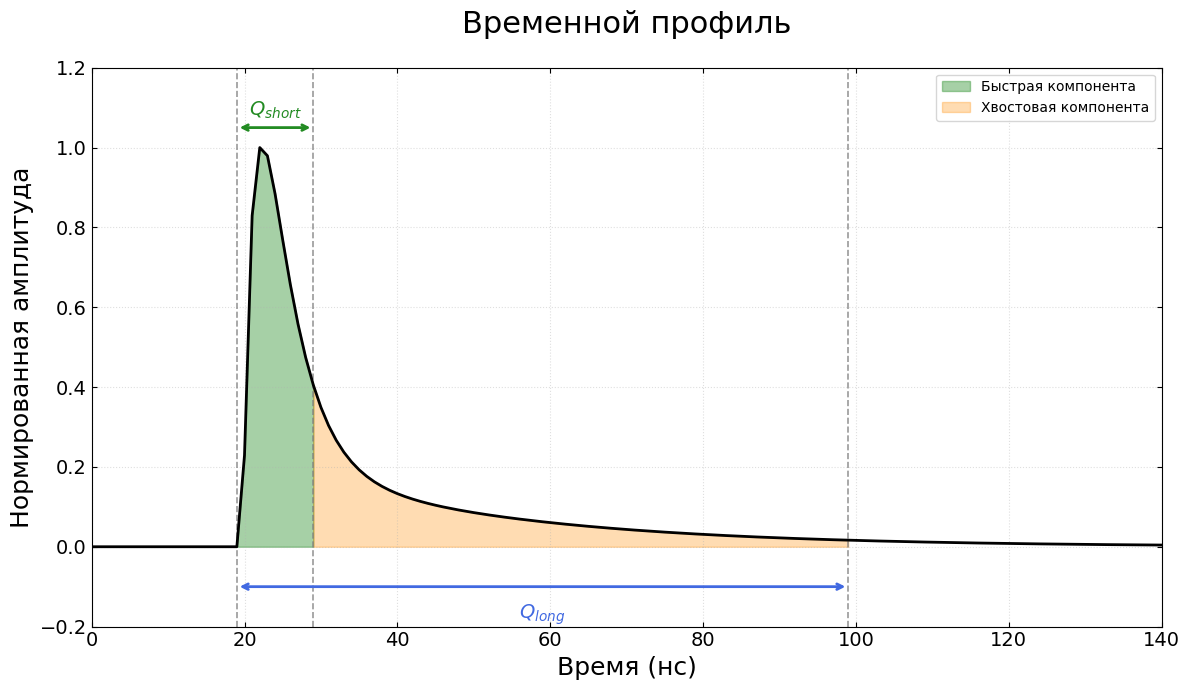

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Выбираем импульс
pulse_idx = 4
pulse = X[pulse_idx] / np.max(X[pulse_idx])
t = np.arange(len(pulse))

# Параметры гейтов
gate_start = 19
short_gate_width = 10
long_gate_width = 80

sg_end = gate_start + short_gate_width
lg_end = gate_start + long_gate_width

plt.figure(figsize=(12, 7))

# 1. Основная линия сигнала
plt.plot(t, pulse, color='black', lw=2, zorder=5)

# 2. Область Q_short (Fast component)
plt.fill_between(t[gate_start : sg_end + 1], pulse[gate_start : sg_end + 1], 
                 color='forestgreen', alpha=0.4, label='Быстрая компонента')

# 3. Область хвоста (Tail)
plt.fill_between(t[sg_end : lg_end + 1], pulse[sg_end : lg_end + 1], 
                 color='darkorange', alpha=0.3, label='Хвостовая компонента')

# --- СТИЛИЗАЦИЯ ЛИНИЙ ---
# Делаем все границы гейтов пунктиром одного нейтрального цвета
gate_line_style = dict(color='gray', linestyle='--', lw=1.2, alpha=0.8)
plt.axvline(x=gate_start, **gate_line_style)
plt.axvline(x=sg_end, **gate_line_style)
plt.axvline(x=lg_end, **gate_line_style)

# --- ПОДПИСИ СО СТРЕЛКАМИ ---

# Q_short (Сверху)
plt.annotate('', xy=(gate_start, 1.05), xytext=(sg_end, 1.05),
             arrowprops=dict(arrowstyle='<->', color='forestgreen', lw=2))
plt.text((gate_start + sg_end) / 2, 1.08, '$Q_{short}$', 
         color='forestgreen', fontsize=14, ha='center', fontweight='bold')

# Q_long (Снизу)
y_min = -0.1
plt.annotate('', xy=(gate_start, y_min), xytext=(lg_end, y_min),
             arrowprops=dict(arrowstyle='<->', color='royalblue', lw=2))
plt.text((gate_start + lg_end) / 2, y_min - 0.08, '$Q_{long}$', 
         color='royalblue', fontsize=14, ha='center', fontweight='bold')

# Оформление
plt.title("Временной профиль", fontsize=22, pad=25)
plt.xlabel("Время (нс)", fontsize=18)
plt.ylabel("Нормированная амплитуда", fontsize=18)

# Лимиты с запасом под подписи
plt.ylim(-0.2, 1.2)
plt.xlim(0, 140)

plt.grid(True, which='both', linestyle=':', alpha=0.4)
plt.legend(loc='upper right')
plt.tick_params(axis='both', which='both', direction='in', labelsize=14, top=True, right=True)
plt.tight_layout()
plt.show()

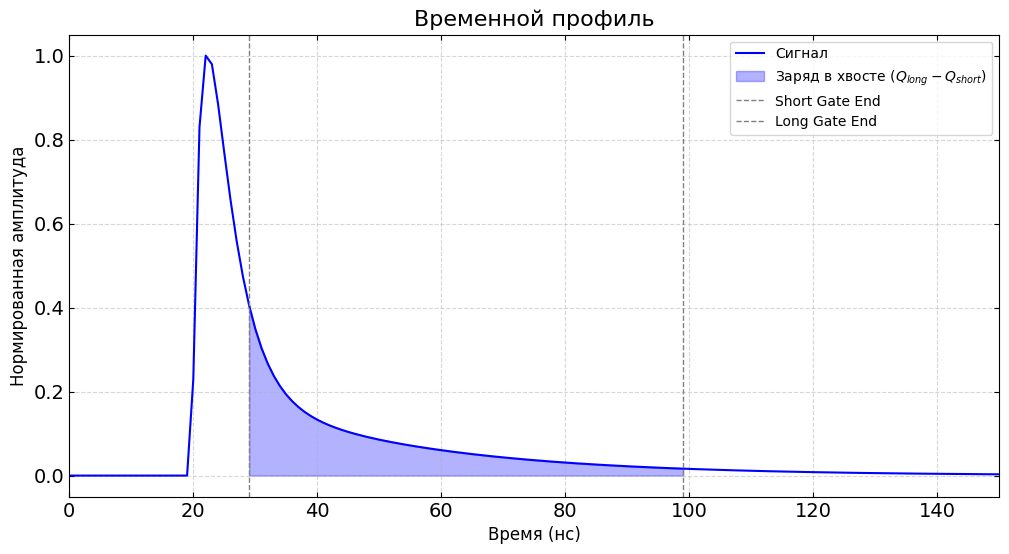

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Выбираем импульс
pulse_idx = 4
pulse = X[pulse_idx]/np.max(X[pulse_idx])
t = np.arange(len(pulse))

# Параметры гейтов
gate_start = 19
short_gate_width = 10
long_gate_width = 80

sg_end = gate_start + short_gate_width
lg_end = gate_start + long_gate_width

plt.figure(figsize=(12, 6))

# 1. Линия импульса
plt.plot(t, pulse, color='blue', lw=1.5, label='Сигнал')

# 2. Закрашиваем ТОЛЬКО область хвоста (Tail)
# Это и есть физическая визуализация числителя (Q_long - Q_short)
plt.fill_between(t[sg_end:lg_end+1], pulse[sg_end:lg_end+1], 
                 color='blue', alpha=0.3, label='Заряд в хвосте ($Q_{long} - Q_{short}$)')

# 3. Тонкие линии границ для понимания, откуда взялся хвост
plt.axvline(x=sg_end, color='gray', linestyle='--', lw=1, label='Short Gate End')
plt.axvline(x=lg_end, color='gray', linestyle='--', lw=1, label='Long Gate End')

# Оформление без лишнего шума
plt.title("Временной профиль", fontsize=16)
plt.xlabel("Время (нс)", fontsize=12)
plt.ylabel("Нормированная амплитуда", fontsize=12)
plt.xlim(0, 150) # Зуммируем на важную часть
plt.legend()

plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tick_params(axis='both', which='both', direction='in', labelsize=14, top=True, right=True)
plt.show()

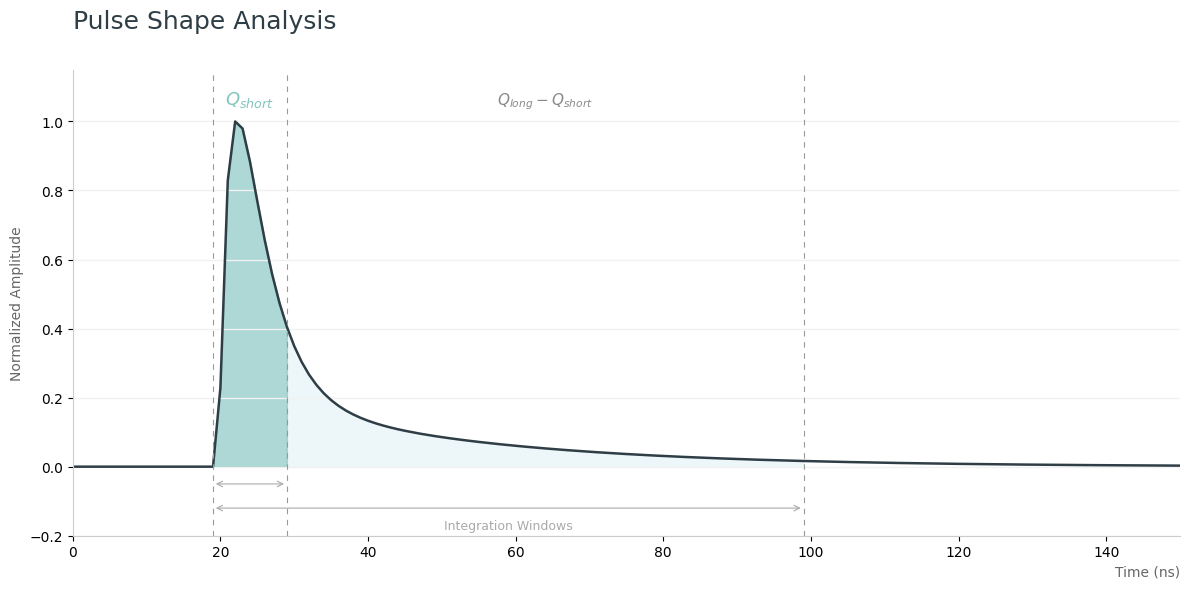

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Предполагаем, что X уже определен в твоем окружении
pulse_idx = 4
pulse = X[pulse_idx] / np.max(X[pulse_idx])
t = np.arange(len(pulse))

# Параметры гейтов
gate_start = 19
short_gate_width = 10
long_gate_width = 80

sg_end = gate_start + short_gate_width
lg_end = gate_start + long_gate_width

# Цветовая палитра (Pastel & Modern)
colors = {
    'pulse': '#2F3E46',      # Глубокий графитовый
    'short': '#83C5BE',      # Мягкая бирюза
    'long': '#EDF6F9',       # Едва заметный голубой (фон)
    'accent': '#E29578',     # Пастельный терракот для акцентов
    'grid': '#F1F1F1'        # Почти белый для сетки
}

fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

# Настройка фона и рамок
ax.set_facecolor('white')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

# 1. Заливка Q_long (общая область)
ax.fill_between(t, pulse, where=(t >= gate_start) & (t <= lg_end),
                color=colors['long'], alpha=1, label='Long Gate Area')

# 2. Заливка Q_short (акцентная область внутри)
ax.fill_between(t, pulse, where=(t >= gate_start) & (t <= sg_end),
                color=colors['short'], alpha=0.6, label='Short Gate Area')

# 3. Линия импульса (поверх всего)
ax.plot(t, pulse, color=colors['pulse'], lw=1.8, antialiased=True)

# 4. Деликатные вертикальные разделители
gate_line_style = {'color': '#999999', 'linestyle': (0, (5, 5)), 'lw': 0.8}
ax.axvline(gate_start, **gate_line_style)
ax.axvline(sg_end, **gate_line_style)
ax.axvline(lg_end, **gate_line_style)

# 5. Аннотации гейтов (делаем "шапку")
# Рисуем горизонтальные скобки или просто подписываем интервалы
text_y = 1.05  # Высота подписей над графиком
ax.text(gate_start + (short_gate_width/2), text_y, '$Q_{short}$', 
        ha='center', weight='bold', color=colors['short'], fontsize=13)

ax.text(sg_end + (lg_end - sg_end)/2, text_y, '$Q_{long} - Q_{short}$', 
        ha='center', color='#888888', fontsize=11)

# Маленькие стрелочки-указатели для интервалов у оси X
arrow_props = dict(arrowstyle='<->', color='#AAAAAA', lw=0.8)
ax.annotate('', xy=(gate_start, -0.05), xytext=(sg_end, -0.05), arrowprops=arrow_props)
ax.annotate('', xy=(gate_start, -0.12), xytext=(lg_end, -0.12), arrowprops=arrow_props)
ax.text((gate_start + lg_end)/2, -0.18, 'Integration Windows', ha='center', fontsize=9, color='#AAAAAA')

# Финальное оформление
ax.set_title("Pulse Shape Analysis", loc='left', fontsize=18, pad=30, color=colors['pulse'], weight='light')
ax.set_xlabel("Time (ns)", loc='right', color='#666666')
ax.set_ylabel("Normalized Amplitude", color='#666666')

ax.set_xlim(0, 150)
ax.set_ylim(-0.2, 1.15) # Оставили место снизу для доп. меток

ax.grid(axis='y', color=colors['grid'], linestyle='-', lw=1)
plt.tight_layout()

plt.show()

### создаю датафрейм для x и будущих признаков




In [31]:
#для признаков
data_fetures = {
    'amplitudes': amplitudes,
    'target': y
}
feature_df = pd.DataFrame(data_fetures)
feature_df.rename_axis('pulse_id')

#для импульсов

X_df = pd.DataFrame(X)
X_df.rename_axis('pulse_id')
print("таблицы созданы")

таблицы созданы


**Нормировка сигнала**

In [28]:
X_df = X_df.apply(lambda row: row / np.max(row), axis=1)

### полная энергия и расчет PSD



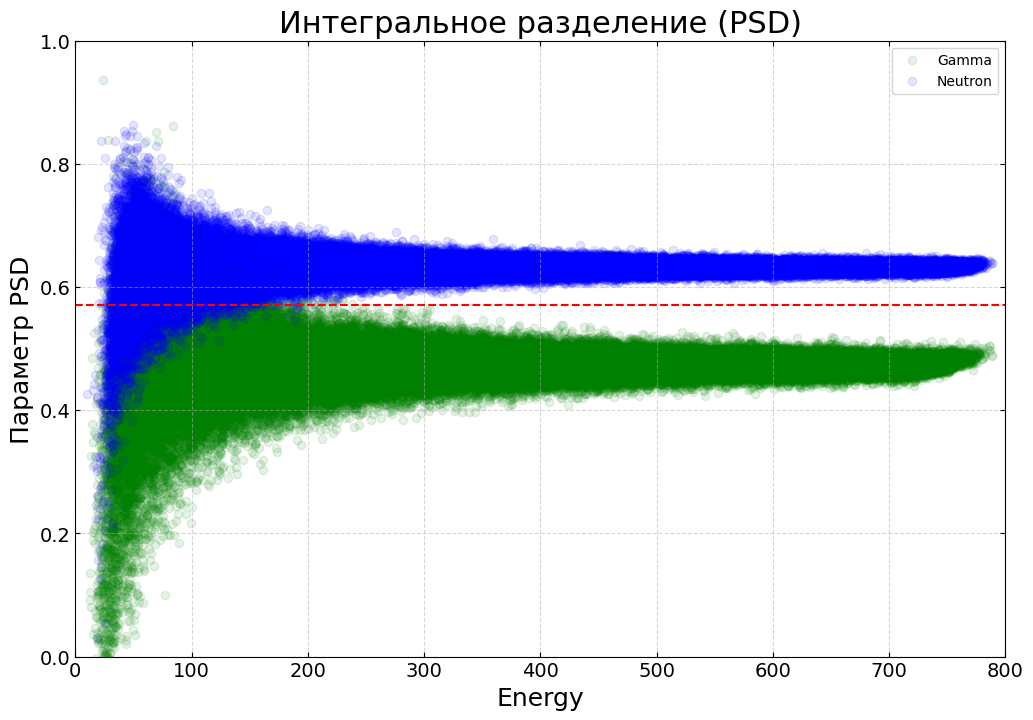

Accuracy with CAEN logic: 0.9757


In [37]:

# --- ПАРАМЕТРЫ ИЗ СТАТЬИ (в семплах) ---
gate_start = 19       # Начало интеграции (Trigger + Pre-gate)
short_gate_width = 10 # Длина короткого гейта (от начала до конца пика)
long_gate_width = 80  # Длина длинного гейта (весь импульс с хвостом)

# Переводим в понятные для срезов индексы
sg_end = gate_start + short_gate_width
lg_end = gate_start + long_gate_width

# --- РАСЧЕТ ПО ЛОГИКЕ CAEN DPP-PSD ---

# 1. Считаем Q_short и Q_long (простая сумма накопленных кодов ADC)
feature_df['Q_short'] = [np.sum(pulse[gate_start : sg_end]) for pulse in X]
feature_df['Q_long'] = [np.sum(pulse[gate_start : lg_end]) for pulse in X]

# 2. Формула PSD из мануала: (Q_Long - Q_Short) / Q_Long
# Это и есть отношение площади хвоста к полной площади
feature_df['psd'] = (feature_df['Q_long'] - feature_df['Q_short']) / feature_df['Q_long']

# --- ОТРИСОВКА (сохраняю твою структуру) ---
gamma_mask = feature_df['target'] == 1
neutron_mask = feature_df['target'] == 0

# Коэффициент для нормировки оси X (энергии), если нужно
factor = np.max(feature_df['Q_long'][neutron_mask]) / np.max(feature_df['Q_long'][gamma_mask])

plt.figure(figsize=(12, 8))
plt.scatter(feature_df['Q_long'][gamma_mask] * factor, feature_df['psd'][gamma_mask], 
            color='green', alpha=0.1, label='Gamma')
plt.scatter(feature_df['Q_long'][neutron_mask], feature_df['psd'][neutron_mask], 
            color='blue', alpha=0.1, label='Neutron')

plt.ylim(0, 1)
plt.xlim(0, 800) # чтобы график не улетал
plt.title("Интегральное разделение (PSD)", fontsize=22)
plt.xlabel("Energy", fontsize=18)
plt.ylabel("Параметр PSD", fontsize=18)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tick_params(axis='both', which='both', direction='in', labelsize=14, top=True, right=True)

plt.axhline(y=0.57, color='red', linestyle='--')
plt.show()

# Оценка точности
best_t = 0.57 # Порог нужно подбирать под твои данные
feature_df['psd_preds'] = (feature_df['psd'] < best_t).astype(int)
acc = np.mean(feature_df['target'] == feature_df['psd_preds'])
print(f"Accuracy with CAEN logic: {acc:.4f}")

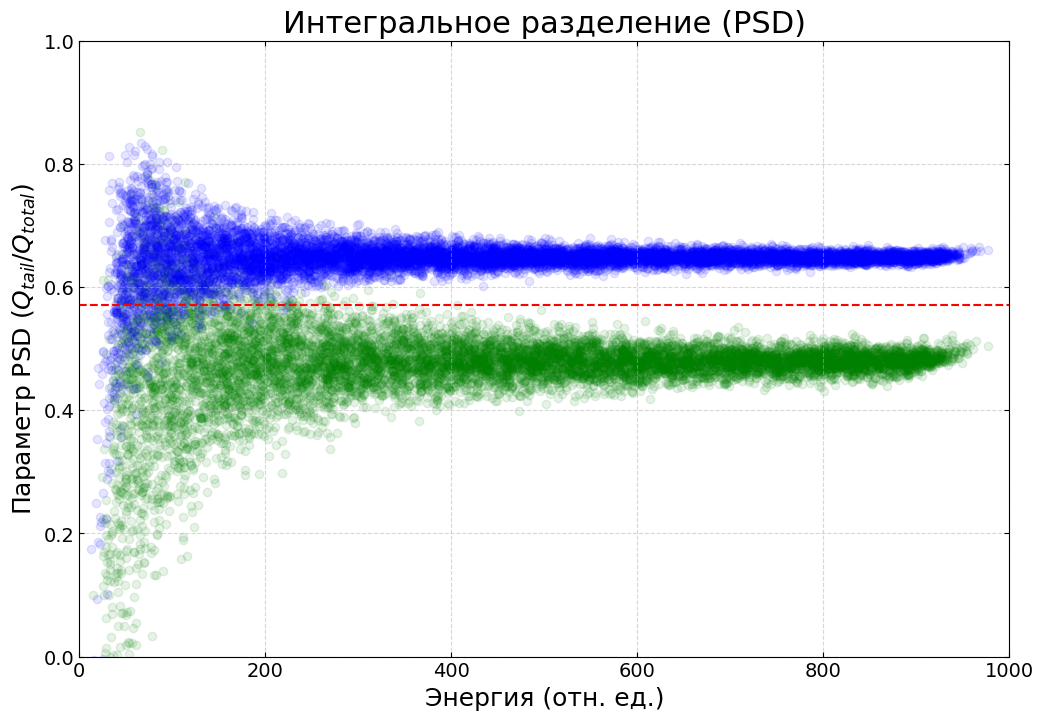

In [24]:
#Параметры интегрирования
tail_time = 29
start_time = 19

# пандас to numpy
X_matrix = X_df.values

# расчет энергий
feature_df['whole_energy'] = [simpson(y=pulse[start_time:], dx=1) for pulse in X]
feature_df['tail_energy'] = [simpson(y=pulse[tail_time:], dx=1) for pulse in X]
feature_df['psd'] = feature_df['tail_energy'] / feature_df['whole_energy']

#Отрисовка  и поиск фактора PSD
gamma_mask = feature_df['target'] == 1
neutron_mask = feature_df['target'] == 0

factor = np.max(feature_df['whole_energy'][neutron_mask]) / np.max(feature_df['whole_energy'][gamma_mask])
plt.figure(figsize=(12, 8))
plt.scatter(feature_df['whole_energy'][gamma_mask] * factor, feature_df['psd'][gamma_mask], color='green', alpha=0.1)
plt.scatter(feature_df['whole_energy'][neutron_mask], feature_df['psd'][neutron_mask], color='blue', alpha=0.1)
plt.ylim(0, 1)
plt.title("Интегральное разделение (PSD)", fontsize=22)
plt.xlabel("Энергия (отн. ед.)", fontsize=18)
plt.ylabel("Параметр PSD ($Q_{tail}/Q_{total}$)", fontsize=18)
# Сетка и риски внутрь
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tick_params(axis='both', which='both', direction='in', labelsize=14, top=True, right=True)
plt.xlim(0, 1000)
plt.axhline(y=0.57, color='red', linestyle='--')
plt.show()



In [17]:
best_t = 0.58
feature_df['psd_preds'] = [int(psd < best_t) for psd in feature_df['psd']]
acc = np.sum((feature_df['target'] == feature_df['psd_preds'])) / len(feature_df)
acc

np.float64(0.967)

In [18]:
feature_df

,amplitudes,target,whole_energy,tail_energy,psd,psd_preds
0,24.236709,1.0,327.260566,161.221694,0.492640,1
1,25.520448,1.0,325.326688,158.070416,0.485882,1
2,2.218258,1.0,41.130110,23.579486,0.573290,1
3,38.728498,1.0,487.381433,232.966578,0.477996,1
4,42.866129,1.0,550.726057,268.585659,0.487694,1
...,...,...,...,...,...,...
19995,7.114005,0.0,178.069509,122.025474,0.685269,0
19996,42.678247,0.0,923.991905,605.019377,0.654789,0
19997,30.641302,0.0,629.728251,407.644807,0.647334,0
19998,6.768861,0.0,136.300398,93.273017,0.684319,0


### Бью импульс на 5 частей


In [19]:
bins_count = 5
X_matrix = X_df.values

bin_width = len(X)
for bin in range(0, bins_count):
    if bin == bins_count - 1:
        feature_df[f'Q_{bin + 1}_bin'] = [simpson(y=pulse[len(pulse) // bins_count * bin:], dx=1) for pulse in X] / feature_df['whole_energy']
    else:
        feature_df[f'Q_{bin + 1}_bin'] = [simpson(y=pulse[len(pulse) // bins_count * bin : len(pulse) // bins_count * (bin + 1)], dx=1) for pulse in X] / feature_df['whole_energy']


In [20]:
feature_df.head()

,amplitudes,target,whole_energy,tail_energy,psd,psd_preds,Q_1_bin,Q_2_bin,Q_3_bin,Q_4_bin,Q_5_bin
0,24.236709,1.0,327.260566,161.221694,0.492640,1,0.677580,0.207625,0.067123,-0.007341,0.010113
1,25.520448,1.0,325.326688,158.070416,0.485882,1,0.699087,0.182257,0.080788,-0.003381,0.019756
2,2.218258,1.0,41.130110,23.579486,0.573290,1,0.481794,0.215150,0.122938,0.044849,0.403891
3,38.728498,1.0,487.381433,232.966578,0.477996,1,0.724534,0.227431,0.038107,0.041063,-0.011386
4,42.866129,1.0,550.726057,268.585659,0.487694,1,0.694622,0.220888,0.060671,0.021267,-0.008131
